# Now analyze the data

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

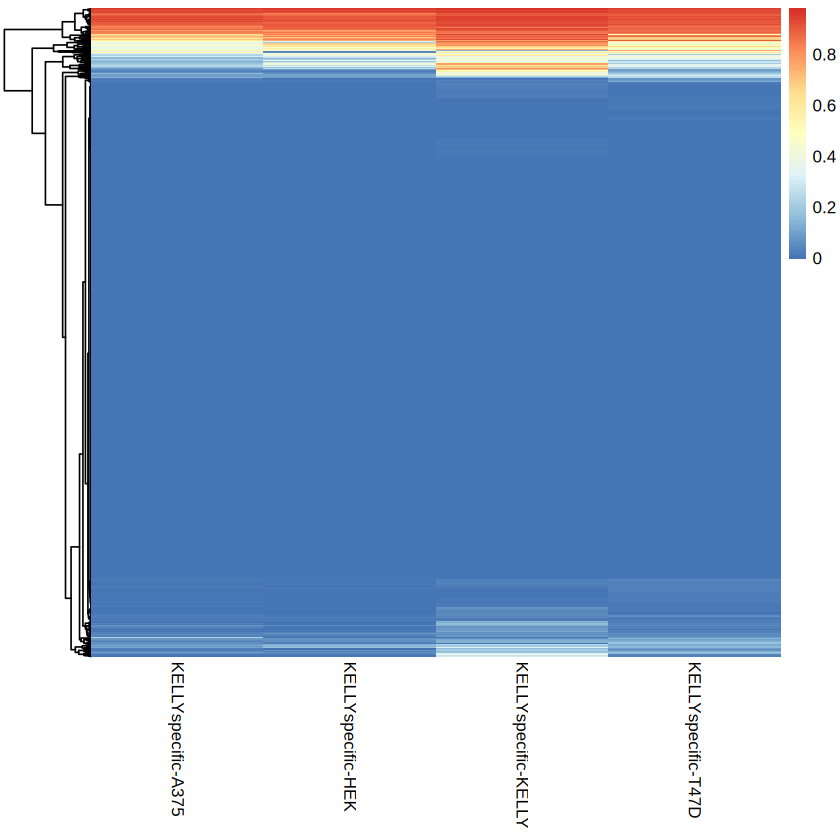

[1] 2245

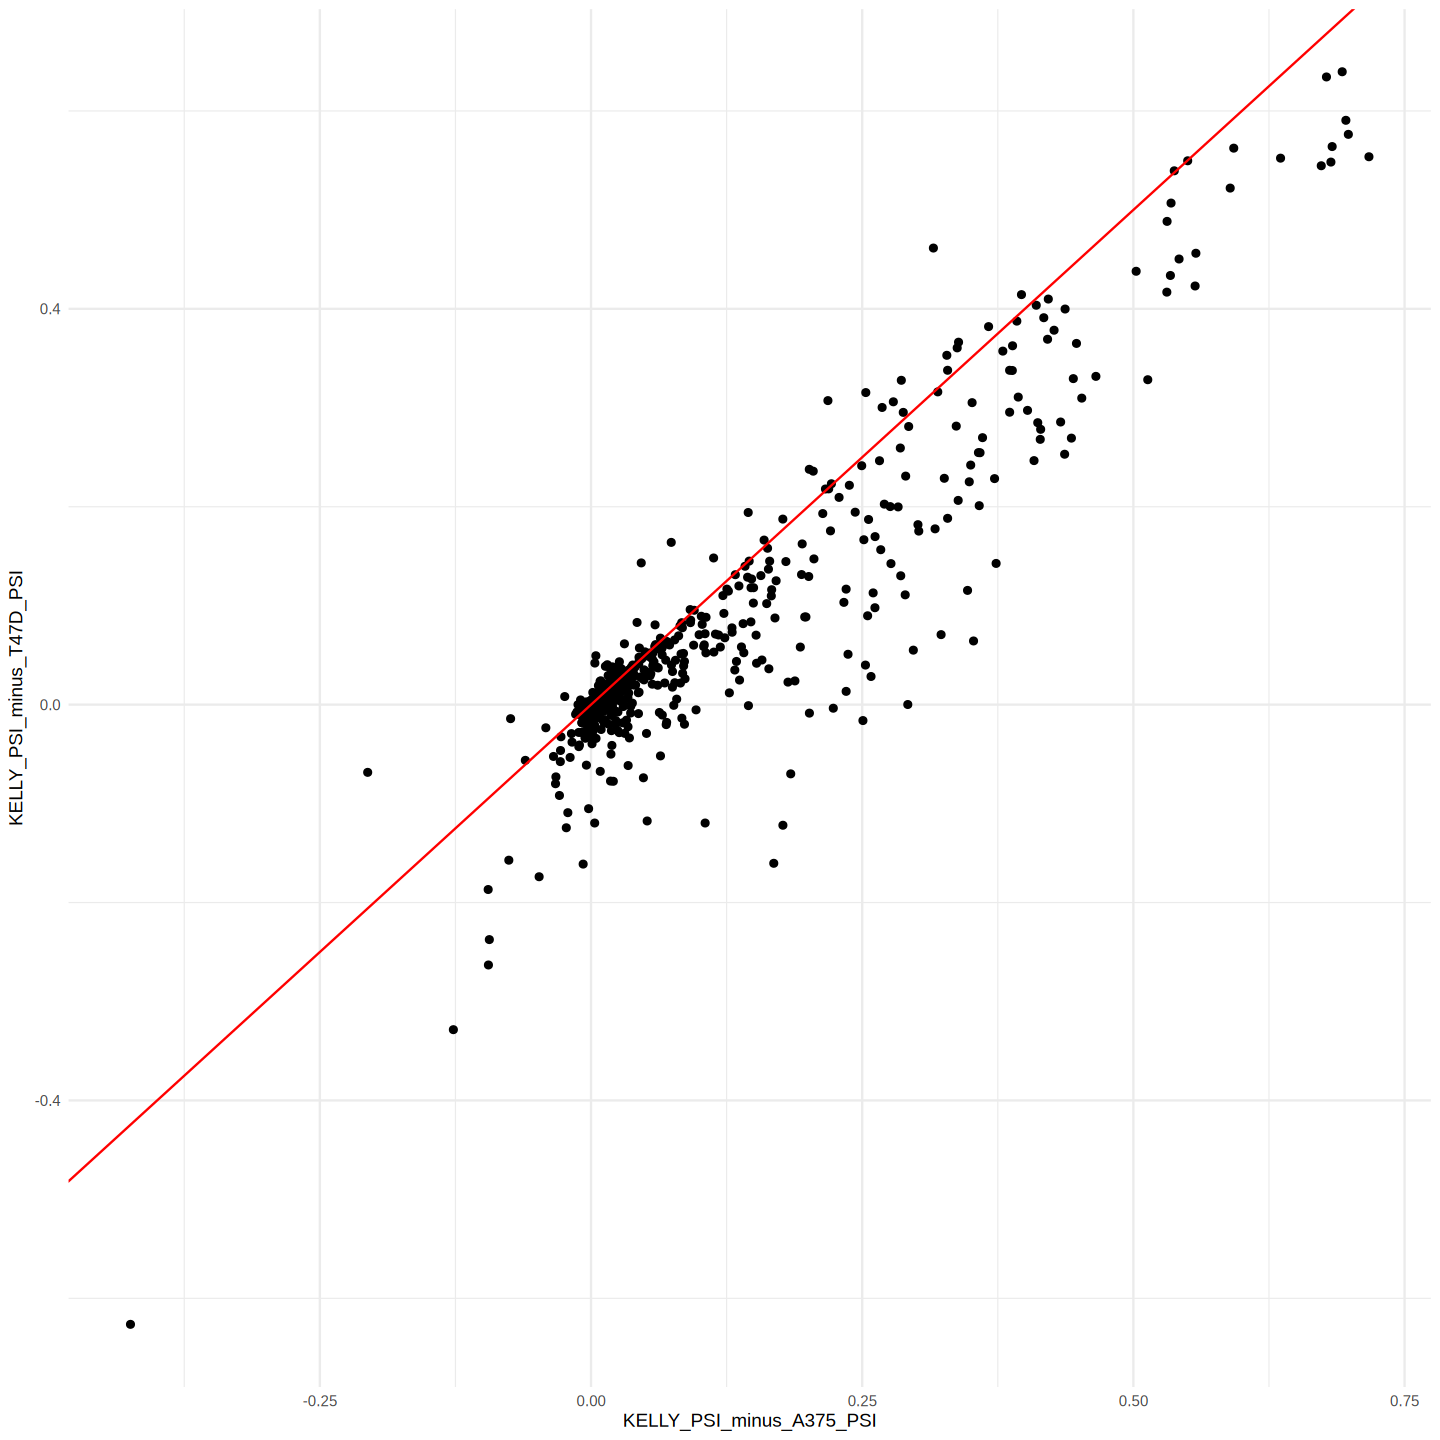

In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(future.apply)
library(pheatmap)

raw_df <- read.csv("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/denovoR2_all_samples_raw_counts.csv")

# Get the unique conditions.
unique_conditions <- unique(raw_df$condition)

# Get the unique samples.
unique_samples <- unique(raw_df$sample)

raw_df_clean <- raw_df %>%
    mutate(index_offset = paste0(index, "__", offset_initial)) %>% 
    select(-filename, - index, - offset_initial) %>%
    filter(mode %in% c("INCLUDED", "SKIPPED")) %>% 
    group_by(sample, condition, index_offset, mode, offset, design) %>%
    summarise(count = sum(count)) %>% 
    arrange(sample, condition, index_offset, design)

raw_df_to_psi <- raw_df_clean %>% 
    group_by(sample, condition, index_offset, mode, design) %>%
    summarise(count = sum(count)) %>% 
    ungroup() %>% 
    pivot_wider(names_from = mode, values_from = count, values_fill = 0) %>%
    mutate(total_counts = INCLUDED + SKIPPED) %>%
    filter(total_counts >= 30) %>%
    mutate(PSI = INCLUDED / total_counts)

# Look at the kelly sequences only. 

raw_df_to_psi_kelly <- raw_df_to_psi %>% 
    filter(grepl("KELLYspecific", condition))
raw_df_to_psi_kelly <- raw_df_to_psi_kelly %>% 
    # filter(design != "R2design0") %>% 
    group_by(condition, index_offset, design) %>% 
    summarise(PSI = mean(PSI)) %>% 
    ungroup() %>% 
    select(condition, index_offset, design, PSI) %>% 
    pivot_wider(names_from = condition, values_from = PSI) %>% 
    mutate(index_offset_design = paste0(index_offset, "___", design))

# Convert to matrix. 
psi_kelly_mat <- as.matrix(raw_df_to_psi_kelly %>% select(-index_offset_design, -index_offset, -design))
rownames(psi_kelly_mat) <- raw_df_to_psi_kelly$index_offset_design

# Remove rows with >20% NA. 
psi_kelly_mat <- psi_kelly_mat[rowMeans(is.na(psi_kelly_mat)) < 0.2, ]
pheatmap(psi_kelly_mat, cluster_rows = TRUE, cluster_cols = FALSE, show_colnames = TRUE, show_rownames = FALSE)

raw_df_to_psi_kelly_filtered <- raw_df_to_psi_kelly %>% 
    mutate(KELLY_PSI_minus_HEK_PSI = `KELLYspecific-KELLY` - `KELLYspecific-HEK`) %>% 
    mutate(KELLY_PSI_minus_A375_PSI = `KELLYspecific-KELLY` - `KELLYspecific-A375`) %>%
    mutate(KELLY_PSI_minus_T47D_PSI = `KELLYspecific-KELLY` - `KELLYspecific-T47D`) 

options(repr.plot.width=12, repr.plot.height=12)
ggplot(raw_df_to_psi_kelly_filtered, aes(x = KELLY_PSI_minus_A375_PSI, y = KELLY_PSI_minus_T47D_PSI)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    theme_minimal() 

nrow(raw_df_to_psi_kelly)

# Now look at cancer specific 

In [2]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)

# Look at the kelly sequences only. 

raw_df_to_psi_cancer <- raw_df_to_psi %>% 
    filter(grepl("CANCERspecific", condition))
# raw_df_to_psi_cancer 

raw_df_to_psi_cancer <- raw_df_to_psi_cancer %>% 
    # filter(design != "R2design0") %>% 
    group_by(condition, index_offset, design) %>% 
    summarise(PSI = mean(PSI)) %>% 
    ungroup() %>% 
    select(condition, index_offset, design, PSI) %>% 
    pivot_wider(names_from = condition, values_from = PSI) %>% 
    mutate(index_offset_design = paste0(index_offset, "___", design))


`summarise()` has grouped output by 'condition', 'index_offset'. You can
override using the `.groups` argument.


In [3]:
colnames(raw_df_to_psi_cancer)
# 'index_offset''design''CANCERspecific-CH3-1-A1''CANCERspecific-Ch3-1-A2''CANCERspecific-FUBP1-B12''CANCERspecific-FUBP1-C8''CANCERspecific-RBM10-C8''CANCERspecific-RBM10-G4''CANCERspecific-RBM5-A2''CANCERspecific-RBM5-A3''CANCERspecific-SF3B1-K700E''CANCERspecific-SF3B1-K700K''CANCERspecific-U2AF1-S34F''CANCERspecific-U2AF1-WT''CANCERspecific-WT''CANCERspecific-ZRSR2-F8''CANCERspecific-ZRSR2-G9''index_offset_design'

[1] "index_offset"               "design"                    
 [3] "CANCERspecific-CH3-1-A1"    "CANCERspecific-Ch3-1-A2"   
 [5] "CANCERspecific-FUBP1-B12"   "CANCERspecific-FUBP1-C8"   
 [7] "CANCERspecific-RBM10-C8"    "CANCERspecific-RBM10-G4"   
 [9] "CANCERspecific-RBM5-A2"     "CANCERspecific-RBM5-A3"    
[11] "CANCERspecific-SF3B1-K700E" "CANCERspecific-SF3B1-K700K"
[13] "CANCERspecific-U2AF1-S34F"  "CANCERspecific-U2AF1-WT"   
[15] "CANCERspecific-WT"          "CANCERspecific-ZRSR2-F8"   
[17] "CANCERspecific-ZRSR2-G9"    "index_offset_design"

In [ ]:
initial_designs <- raw_df_to_psi_cancer %>% filter(design == "R2design0") %>% 
    mutate(CANCERspecific_CH3_1 = (`CANCERspecific-CH3-1-A1` + `CANCERspecific-Ch3-1-A2`) / 2) %>%
    mutate(CANCERspecific_FUBP1 = (`CANCERspecific-FUBP1-B12` + `CANCERspecific-FUBP1-C8`) / 2) %>%
    mutate(CANCERspecific_RBM10 = (`CANCERspecific-RBM10-C8` + `CANCERspecific-RBM10-G4`) / 2) %>%
    mutate(CANCERspecific_RBM5 = (`CANCERspecific-RBM5-A2` + `CANCERspecific-RBM5-A3`) / 2) %>%
    mutate(CANCERspecific_ZRSR2 = (`CANCERspecific-ZRSR2-F8` + `CANCERspecific-ZRSR2-G9`) / 2) %>% 
    select(index_offset, design, CANCERspecific_CH3_1, CANCERspecific_FUBP1, CANCERspecific_RBM10, CANCERspecific_RBM5, CANCERspecific_ZRSR2, `CANCERspecific-U2AF1-S34F`, `CANCERspecific-U2AF1-WT`)

initial_psi_diff_RBM5 <- initial_designs %>% 
    mutate(PSI_diff_initial = CANCERspecific_RBM5 - CANCERspecific_CH3_1) %>%
    mutate(PSI_FC_initial = CANCERspecific_RBM5 / CANCERspecific_CH3_1) %>%
    mutate(mutation_group = "RBM5") %>% 
    mutate(design_group = "RBM5_0_to_pos") %>% 
    mutate(mut_PSI_initial = CANCERspecific_RBM5) %>% 
    mutate(WT_PSI_initial = CANCERspecific_CH3_1) %>% 
    select(index_offset, mutation_group, mut_PSI_initial, WT_PSI_initial, PSI_diff_initial)

initial_psi_diff_RBM10 <- initial_designs %>% 
    mutate(PSI_diff_initial = CANCERspecific_RBM10 - CANCERspecific_CH3_1) %>%
    mutate(PSI_FC_initial = CANCERspecific_RBM10 / CANCERspecific_CH3_1) %>%
    mutate(mutation_group = "RBM10") %>% 
    mutate(design_group = "RBM10_0_to_pos") %>% 
    mutate(mut_PSI_initial = CANCERspecific_RBM10) %>% 
    mutate(WT_PSI_initial = CANCERspecific_CH3_1) %>% 
    select(index_offset, mutation_group, mut_PSI_initial, WT_PSI_initial, PSI_diff_initial)

initial_psi_diff_FUBP1 <- initial_designs %>% 
    mutate(PSI_diff_initial = CANCERspecific_FUBP1 - CANCERspecific_CH3_1) %>%
    mutate(PSI_FC_initial = CANCERspecific_FUBP1 / CANCERspecific_CH3_1) %>%
    mutate(mutation_group = "FUBP1") %>% 
    mutate(design_group = "FUBP1_0_to_pos") %>% 
    mutate(mut_PSI_initial = CANCERspecific_FUBP1) %>% 
    mutate(WT_PSI_initial = CANCERspecific_CH3_1) %>% 
    select(index_offset, mutation_group, mut_PSI_initial, WT_PSI_initial, PSI_diff_initial)

initial_psi_diff_U2AF1S34F <- initial_designs %>% 
    mutate(PSI_diff_initial = `CANCERspecific-U2AF1-S34F` - `CANCERspecific-U2AF1-WT`) %>%
    mutate(PSI_FC_initial = `CANCERspecific-U2AF1-S34F` / `CANCERspecific-U2AF1-WT`) %>% 
    mutate(mutation_group = "U2AF1-S34F") %>% 
    mutate(design_group = "U2AF1S34F_0_to_pos") %>% 
    mutate(mut_PSI_initial = `CANCERspecific-U2AF1-S34F`) %>% 
    mutate(WT_PSI_initial = `CANCERspecific-U2AF1-WT`) %>% 
    select(index_offset, mutation_group, mut_PSI_initial, WT_PSI_initial, PSI_diff_initial)

initial_psi_diff <- bind_rows(initial_psi_diff_RBM5, initial_psi_diff_RBM10, initial_psi_diff_FUBP1, initial_psi_diff_U2AF1S34F)

head(initial_psi_diff)


index_offset,mutation_group,mut_PSI_initial,WT_PSI_initial,PSI_diff_initial
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,RBM5,0.16259965,0.2356690496,-0.073069404
ENSG00000006611.17;USH1C;chr11-17516240-17516290-17501938-17501980-17517400-17517474__0:0:0,RBM5,0.01417677,0.0005770068,0.013599763
ENSG00000008710.20;PKD1;chr16-2108251-2108358-2106940-2106948-2112339-2112473__0:0:0,RBM5,0.05734207,0.0157694136,0.041572659
ENSG00000010310.9;GIPR;chr19-45681603-45681645-45678087-45678226-45681728-45681988__0:0:0,RBM5,0.01644186,0.0050207922,0.011421064
ENSG00000011201.12;ANOS1;chrX-8699697-8699745-8623607-8623670-8731829-8732137__0:0:0,RBM5,0.97144456,0.9703248641,0.001119698
ENSG00000011304.22;PTBP1;chr19-808379-808452-806407-806556-808545-808646__0:0:0,RBM5,0.32269371,0.4791470061,-0.156453294


In [5]:
# Conditions are 
# vae_cancer_RBM5_0_to_pos
# vae_cancer_RBM5_0_to_neg
# vae_cancer_RBM10_0_to_pos
# vae_cancer_RBM10_0_to_neg
# vae_cancer_FUBP1_0_to_pos
# vae_cancer_FUBP1_0_to_neg
# vae_cancer_U2AF1S34F_0_to_pos
# vae_cancer_U2AF1S34F_0_to_neg
raw_df_to_psi_cancer <- raw_df_to_psi_cancer %>% 
    mutate(CANCERspecific_CH3_1 = (`CANCERspecific-CH3-1-A1` + `CANCERspecific-Ch3-1-A2`) / 2) %>%
    mutate(CANCERspecific_FUBP1 = (`CANCERspecific-FUBP1-B12` + `CANCERspecific-FUBP1-C8`) / 2) %>%
    mutate(CANCERspecific_RBM10 = (`CANCERspecific-RBM10-C8` + `CANCERspecific-RBM10-G4`) / 2) %>%
    mutate(CANCERspecific_RBM5 = (`CANCERspecific-RBM5-A2` + `CANCERspecific-RBM5-A3`) / 2) %>%
    mutate(CANCERspecific_ZRSR2 = (`CANCERspecific-ZRSR2-F8` + `CANCERspecific-ZRSR2-G9`) / 2)


raw_df_to_psi_cancer_RBM5_0_to_pos <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_RBM5_0_to_pos", design)) %>% 
    mutate(PSI_diff = `CANCERspecific_RBM5` - `CANCERspecific_CH3_1`)  %>%
    mutate(PSI_FC = `CANCERspecific_RBM5` / `CANCERspecific_CH3_1`) %>%
    mutate(mutation_group = "RBM5") %>% 
    mutate(design_group = "RBM5_0_to_pos") %>%
    mutate(mut_PSI = `CANCERspecific_RBM5`) %>% 
    mutate(WT_PSI = `CANCERspecific_CH3_1`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_RBM5_0_to_neg <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_RBM5_0_to_neg", design)) %>% 
    mutate(PSI_diff = `CANCERspecific_RBM5` - `CANCERspecific_CH3_1`)  %>%
    mutate(PSI_FC = `CANCERspecific_RBM5` / `CANCERspecific_CH3_1`) %>% 
    mutate(mutation_group = "RBM5") %>% 
    mutate(design_group = "RBM5_0_to_neg") %>% 
    mutate(mut_PSI = `CANCERspecific_RBM5`) %>% 
    mutate(WT_PSI = `CANCERspecific_CH3_1`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_RBM10_0_to_pos <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_RBM10_0_to_pos", design)) %>% 
    mutate(PSI_diff = `CANCERspecific_RBM10` - `CANCERspecific_CH3_1`)  %>%
    mutate(PSI_FC = `CANCERspecific_RBM10` / `CANCERspecific_CH3_1`) %>% 
    mutate(mutation_group = "RBM10") %>% 
    mutate(design_group = "RBM10_0_to_pos") %>% 
    mutate(mut_PSI = `CANCERspecific_RBM10`) %>% 
    mutate(WT_PSI = `CANCERspecific_CH3_1`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_RBM10_0_to_neg <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_RBM10_0_to_neg", design)) %>% 
    mutate(PSI_diff = `CANCERspecific_RBM10` - `CANCERspecific_CH3_1`)  %>%
    mutate(PSI_FC = `CANCERspecific_RBM10` / `CANCERspecific_CH3_1`) %>% 
    mutate(mutation_group = "RBM10") %>% 
    mutate(design_group = "RBM10_0_to_neg") %>% 
    mutate(mut_PSI = `CANCERspecific_RBM10`) %>% 
    mutate(WT_PSI = `CANCERspecific_CH3_1`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_FUBP1_0_to_pos <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_FUBP1_0_to_pos",design)) %>% 
    mutate(PSI_diff = `CANCERspecific_FUBP1` - `CANCERspecific_CH3_1`)  %>%
    mutate(PSI_FC = `CANCERspecific_FUBP1` / `CANCERspecific_CH3_1`) %>% 
    mutate(mutation_group = "FUBP1") %>% 
    mutate(design_group = "FUBP1_0_to_pos") %>% 
    mutate(mut_PSI = `CANCERspecific_FUBP1`) %>% 
    mutate(WT_PSI = `CANCERspecific_CH3_1`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_FUBP1_0_to_neg <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_FUBP1_0_to_neg",design)) %>% 
    mutate(PSI_diff = `CANCERspecific_FUBP1` - `CANCERspecific_CH3_1`)  %>%
    mutate(PSI_FC = `CANCERspecific_FUBP1` / `CANCERspecific_CH3_1`) %>% 
    mutate(mutation_group = "FUBP1") %>% 
    mutate(design_group = "FUBP1_0_to_neg") %>% 
    mutate(mut_PSI = `CANCERspecific_FUBP1`) %>% 
    mutate(WT_PSI = `CANCERspecific_CH3_1`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_U2AF1S34F_0_to_pos <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_U2AF1S34F_0_to_pos",design)) %>% 
    mutate(PSI_diff = `CANCERspecific-U2AF1-S34F` - `CANCERspecific-U2AF1-WT`)  %>%
    mutate(PSI_FC = `CANCERspecific-U2AF1-S34F` / `CANCERspecific-U2AF1-WT`) %>% 
    mutate(mutation_group = "U2AF1-S34F") %>% 
    mutate(design_group = "U2AF1S34F_0_to_pos") %>% 
    mutate(mut_PSI = `CANCERspecific-U2AF1-S34F`) %>% 
    mutate(WT_PSI = `CANCERspecific-U2AF1-WT`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

raw_df_to_psi_cancer_U2AF1S34F_0_to_neg <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_U2AF1S34F_0_to_neg",design)) %>% 
    mutate(PSI_diff = `CANCERspecific-U2AF1-S34F` - `CANCERspecific-U2AF1-WT`)  %>%
    mutate(PSI_FC = `CANCERspecific-U2AF1-S34F` / `CANCERspecific-U2AF1-WT`) %>% 
    mutate(mutation_group = "U2AF1-S34F") %>% 
    mutate(design_group = "U2AF1S34F_0_to_neg") %>% 
    mutate(mut_PSI = `CANCERspecific-U2AF1-S34F`) %>% 
    mutate(WT_PSI = `CANCERspecific-U2AF1-WT`) %>% 
    select(index_offset, design, index_offset_design, mutation_group, design_group, mut_PSI, WT_PSI, PSI_diff, PSI_FC)

# Combine all the dataframes. 
raw_df_to_psi_cancer_combined <- bind_rows(raw_df_to_psi_cancer_RBM5_0_to_pos, raw_df_to_psi_cancer_RBM5_0_to_neg, raw_df_to_psi_cancer_RBM10_0_to_pos, raw_df_to_psi_cancer_RBM10_0_to_neg, raw_df_to_psi_cancer_FUBP1_0_to_pos, raw_df_to_psi_cancer_FUBP1_0_to_neg, raw_df_to_psi_cancer_U2AF1S34F_0_to_pos, raw_df_to_psi_cancer_U2AF1S34F_0_to_neg)


# Merge the initial set with the designed set

In [6]:
raw_df_to_psi_cancer_with_initial <- merge(raw_df_to_psi_cancer_combined, initial_psi_diff, by = c("index_offset", "mutation_group"), all.x = TRUE)
head(raw_df_to_psi_cancer_with_initial)

,index_offset,mutation_group,design,index_offset_design,design_group,mut_PSI,WT_PSI,PSI_diff,PSI_FC,mut_PSI_initial,WT_PSI_initial,PSI_diff_initial
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,U2AF1-S34F,vae_cancer_U2AF1S34F_0_to_neg_R2design7,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0___vae_cancer_U2AF1S34F_0_to_neg_R2design7,U2AF1S34F_0_to_neg,0.02696108,0.021788873,0.005172208,1.2373784,0.1059979,0.1216001,-0.01560224
2,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,U2AF1-S34F,vae_cancer_U2AF1S34F_0_to_neg_R2design5,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0___vae_cancer_U2AF1S34F_0_to_neg_R2design5,U2AF1S34F_0_to_neg,0.00000000,0.004975124,-0.004975124,0.0000000,0.1059979,0.1216001,-0.01560224
3,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,U2AF1-S34F,vae_cancer_U2AF1S34F_0_to_neg_R2design2,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0___vae_cancer_U2AF1S34F_0_to_neg_R2design2,U2AF1S34F_0_to_neg,NA,NA,NA,NA,0.1059979,0.1216001,-0.01560224
4,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,U2AF1-S34F,vae_cancer_U2AF1S34F_0_to_neg_R2design6,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0___vae_cancer_U2AF1S34F_0_to_neg_R2design6,U2AF1S34F_0_to_neg,0.00000000,0.009174312,-0.009174312,0.0000000,0.1059979,0.1216001,-0.01560224
5,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,U2AF1-S34F,vae_cancer_U2AF1S34F_0_to_neg_R2design3,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0___vae_cancer_U2AF1S34F_0_to_neg_R2design3,U2AF1S34F_0_to_neg,0.00000000,0.000000000,0.000000000,NaN,0.1059979,0.1216001,-0.01560224
6,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,U2AF1-S34F,vae_cancer_U2AF1S34F_0_to_neg_R2design4,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0___vae_cancer_U2AF1S34F_0_to_neg_R2design4,U2AF1S34F_0_to_neg,0.01321568,0.014533121,-0.001317444,0.9093488,0.1059979,0.1216001,-0.01560224


Warning message:
“Removed 317 rows containing missing values or values outside the scale range
(`geom_point()`).”


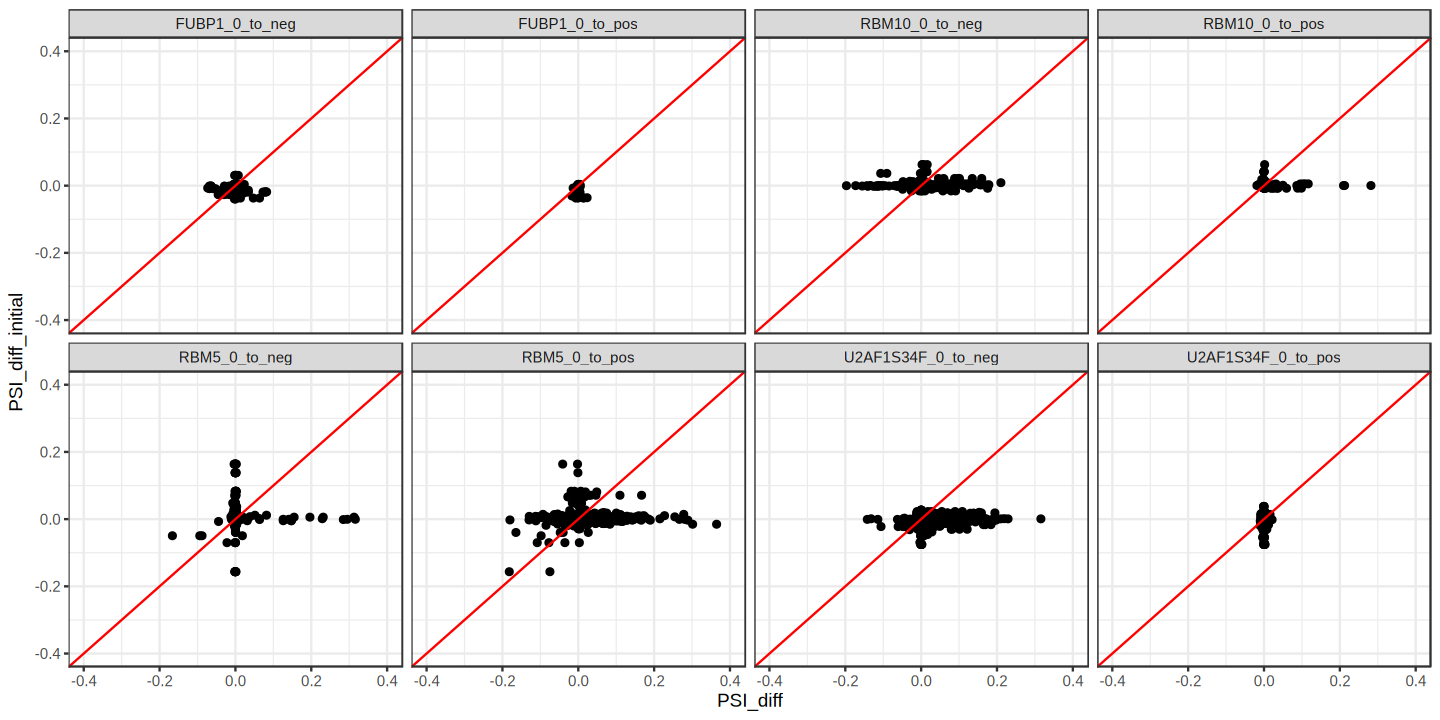

In [14]:
options(repr.plot.width=12, repr.plot.height=6)
ggplot(raw_df_to_psi_cancer_with_initial, aes(x = PSI_diff, y = PSI_diff_initial)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    facet_wrap(~design_group, nrow = 2) +
    xlim(-0.4, 0.4) +
    ylim(-0.4, 0.4) +
    theme_bw()


In [8]:
raw_df_to_psi_cancer %>% filter(index_offset == "ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0")

index_offset,design,CANCERspecific-CH3-1-A1,CANCERspecific-Ch3-1-A2,CANCERspecific-FUBP1-B12,CANCERspecific-FUBP1-C8,CANCERspecific-RBM10-C8,CANCERspecific-RBM10-G4,CANCERspecific-RBM5-A2,CANCERspecific-RBM5-A3,⋯,CANCERspecific-U2AF1-WT,CANCERspecific-WT,CANCERspecific-ZRSR2-F8,CANCERspecific-ZRSR2-G9,index_offset_design,CANCERspecific_CH3_1,CANCERspecific_FUBP1,CANCERspecific_RBM10,CANCERspecific_RBM5,CANCERspecific_ZRSR2
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,R2design0,0.975486049,0.965828707,0.947657704,0.939971207,0.973621317,0.977055354,0.970393416,0.970045981,⋯,0.9487882459,0.965736696,0.972260520,0.963496082,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___R2design0,0.970657378,0.943814455,0.975338336,0.970219699,0.967878301
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design1,0.000000000,0.006388740,0.004164417,0.008770181,0.004109849,0.008944574,0.005554524,0.004183804,⋯,0.0005537466,0.002935414,0.004353753,0.007875616,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design1,0.003194370,0.006467299,0.006527211,0.004869164,0.006114685
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design2,0.062463147,0.081456783,0.158141148,0.197578241,0.326826843,0.313983051,0.368349979,0.365887553,⋯,0.0090663048,0.174411319,0.057546911,0.075006163,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design2,0.071959965,0.177859695,0.320404947,0.367118766,0.066276537
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design3,0.023473933,0.024990773,0.060538837,0.068092729,0.151149716,0.126286343,0.167485232,0.133032969,⋯,0.0025409701,0.070137300,0.029618323,0.037417742,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design3,0.024232353,0.064315783,0.138718030,0.150259100,0.033518033
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design4,0.020140381,0.024590500,0.087380477,0.044758065,0.113691630,0.132796258,0.174959838,0.150943752,⋯,0.0051126687,0.051628525,0.023183841,0.025181016,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design4,0.022365440,0.066069271,0.123243944,0.162951795,0.024182429
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design5,0.002743489,0.002008032,0.000000000,0.003597122,0.002309469,0.000000000,0.003079577,0.001818182,⋯,0.0008912656,0.001066098,0.002283105,0.004975124,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design5,0.002375761,0.001798561,0.001154734,0.002448879,0.003629115
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design7,0.098172020,0.072927921,0.181939024,0.206632653,0.339295180,0.420948204,0.433026942,0.370371452,⋯,0.0046703692,0.182989297,0.062465792,0.104124408,ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0___vae_cancer_RBM5_0_to_neg_R2design7,0.085549970,0.194285838,0.380121692,0.401699197,0.083295100
ENSG00000160392.14;C19orf47;chr19-40333850-40333929-40328412-40328550-40336109-40336224__0:0:0,vae_cancer_RBM5_0_to_neg_R2design8,0.252542865,0.264554135,0.380632955,0.508577964,0.593900725,0.638405797,0.664171657,0.65